# 05 — Head Ordinal: Menilai Kematangan pada Crop

Detektor menjawab **di mana** tandannya. Notebook ini membangun komponen yang
menjawab **seberapa matang** — dan ini bagian yang dirancang sendiri
sepenuhnya, bukan modifikasi kerangka kerja orang lain.

## Kenapa bukan klasifikasi biasa

Tingkat kematangan itu **berurutan**:

```
mentah  <  kurang masak  <  masak  <  terlalu masak
```

Cross-entropy memperlakukan keempatnya sebagai kategori terpisah tanpa urutan,
sehingga menganggap dua kesalahan ini sama beratnya:

| Sebenarnya | Ditebak | Kerugian nyata |
|---|---|---|
| masak | terlalu masak | kecil — selisih satu tingkat |
| mentah | terlalu masak | besar — potongan pembayaran petani meleset jauh |

Untuk sistem yang keluarannya dipakai memotong uang orang, membiarkan kedua
kesalahan itu dihukum sama adalah cacat desain, bukan detail teknis.

## CORAL — cara memasukkan urutan ke dalam loss

Alih-alih memilih satu dari empat kelas, model menjawab **tiga pertanyaan
biner berjenjang**:

```
  P(tingkat > mentah)        -> sigmoid
  P(tingkat > kurang masak)  -> sigmoid
  P(tingkat > masak)         -> sigmoid
```

Prediksi akhir = berapa banyak ambang yang terlewati. Bobot lapisan akhir
**dibagi bersama**, hanya biasnya yang berbeda per ambang — inilah yang
menjamin urutan tidak pernah dilanggar (probabilitas berjenjang selalu monoton).

## Rancangan eksperimen

| Tahap | Data | Tujuan |
|---|---|---|
| Pra-latih | 4.728 citra buah tunggal, 5 tingkat | membentuk representasi kematangan |
| Penyesuaian | 11.102 crop dari tumpukan, 4 tingkat | menyesuaikan ke kondisi kerja nyata |

Dua head dibandingkan **di atas backbone hasil pra-latih yang sama**, supaya
yang diuji benar-benar fungsi loss-nya, bukan keberuntungan inisialisasi:

- **CE** — klasifikasi biasa, 4 keluaran
- **CORAL** — 3 ambang berjenjang

Metrik utamanya **MAE indeks kelas**, bukan akurasi. Akurasi tidak membedakan
salah satu tingkat dari salah tiga tingkat.

In [1]:
from pathlib import Path
import sys, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd()))
import vizstyle as vs
vs.apply_style()

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

ROOT = Path.cwd().parents[1]
CROPS = ROOT / "data" / "processed" / "crops_ordinal"
ORD5 = ROOT / "data" / "raw" / "ordinal-kalteng" / "Dataset" / "Dataset"

DEV = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42); np.random.seed(42)
print("device :", torch.cuda.get_device_name(0) if DEV.type == "cuda" else "CPU")
print("crops  :", CROPS.exists(), "| ordinal5 :", ORD5.exists())

device : NVIDIA GeForce RTX 4050 Laptop GPU
crops  : True | ordinal5 : True


## 1. Data

Augmentasi pada tahap pra-latih sengaja **meniru kerusakan crop**: citra sumber
seragam 256x256 dan persegi sempurna, sedangkan crop nyata lebih kecil, lebih
buram, dan rasio aspeknya bervariasi 0,78-1,96. Tanpa augmentasi yang meniru
itu, head akan kaget saat pertama kali melihat crop asli.

In [2]:
SIZE = 128
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

aug_pralatih = transforms.Compose([
    # rasio aspek diacak: citra sumber semuanya persegi, crop nyata tidak
    transforms.RandomResizedCrop(SIZE, scale=(0.7, 1.0), ratio=(0.7, 1.45)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.35, 0.35, 0.3, 0.04),
    transforms.RandomApply([transforms.GaussianBlur(5, (0.3, 1.8))], p=0.35),
    # turunkan lalu naikkan resolusi -> meniru crop beresolusi rendah
    transforms.RandomApply([transforms.Resize(56), transforms.Resize(SIZE)], p=0.3),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.12)),
])

aug_latih = transforms.Compose([
    transforms.RandomResizedCrop(SIZE, scale=(0.75, 1.0), ratio=(0.75, 1.4)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.3, 0.3, 0.25, 0.03),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD),
])

tf_eval = transforms.Compose([
    transforms.Resize((SIZE, SIZE)),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD),
])

class CropDS(Dataset):
    def __init__(self, df, tf):
        self.df = df.reset_index(drop=True); self.tf = tf
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = Image.open(r["path"]).convert("RGB")
        return self.tf(img), int(r["ordinal"])

# --- crop dari tumpukan (4 tingkat) ---
crops = pd.read_csv(CROPS / "index.csv")
print("crop per split:")
print(crops.groupby(["split", "label"]).size().unstack(fill_value=0).to_string())

# --- dataset buah tunggal (5 tingkat) ---
rows = []
for d in sorted((ORD5 / "Images").iterdir()):
    if d.is_dir():
        for f in d.glob("*.jpg"):
            rows.append({"path": str(f), "ordinal": int(d.name[0]), "file": f.name})
ord5 = pd.DataFrame(rows)
smap = {}
for nama, k in [("Training.txt", "train"), ("Validation.txt", "val"),
                ("Testing.txt", "test")]:
    p = ORD5 / "Train_val_test_split" / nama
    if p.exists():
        for line in p.read_text().split():
            smap[line.strip()] = k
ord5["split"] = ord5["file"].map(smap)
print(f"\npra-latih: {len(ord5):,} citra, {ord5.ordinal.nunique()} tingkat")

crop per split:
label  0_mentah  1_kurang_masak  2_masak  3_terlalu_masak
split                                                    
test        534             354      245              351
train      1771            1856     2411             1800
val         608             365      317              490



pra-latih: 4,728 citra, 5 tingkat


## 2. Arsitektur

Backbone ResNet-18 pra-terlatih ImageNet — fitur visual dasar tidak perlu
dipelajari ulang dari 7.838 crop. Yang dibangun sendiri adalah **kepalanya**,
dan di situlah seluruh perbedaannya.

In [3]:
class CoralHead(nn.Module):
    """K-1 ambang berjenjang dengan BOBOT DIBAGI BERSAMA.

    Kunci CORAL: satu vektor bobot `w` untuk semua ambang, hanya bias yang
    berbeda. Karena skornya sama dan hanya digeser bias, urutan probabilitas
    antar ambang tidak mungkin terbalik — model secara struktural tidak bisa
    mengatakan "lebih dari masak" tanpa juga "lebih dari mentah".
    """
    def __init__(self, in_dim: int, n_kelas: int):
        super().__init__()
        self.fc = nn.Linear(in_dim, 1, bias=False)
        self.bias = nn.Parameter(torch.zeros(n_kelas - 1))
    def forward(self, x):
        return self.fc(x) + self.bias          # (B, K-1)

class CoralHeadMLP(nn.Module):
    '''Varian CORAL dengan leher MLP.

    CORAL baku memampatkan seluruh vektor fitur menjadi SATU skor lewat satu
    lapisan linear. Itu hambatan rank-1: model dipaksa mengasumsikan kematangan
    dapat diproyeksikan ke satu garis lurus langsung dari fitur mentah.

    Varian ini menyisipkan lapisan tersembunyi sebelum proyeksi akhir, sehingga
    proyeksi 1-D itu dipelajari dari representasi yang lebih kaya. Jaminan
    urutan TIDAK hilang: ujungnya tetap satu skor + K-1 bias, jadi probabilitas
    berjenjang tetap monoton secara struktural.
    '''
    def __init__(self, in_dim: int, n_kelas: int, hidden: int = 256):
        super().__init__()
        self.neck = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(inplace=True), nn.Dropout(0.2))
        self.fc = nn.Linear(hidden, 1, bias=False)
        self.bias = nn.Parameter(torch.zeros(n_kelas - 1))
    def forward(self, x):
        return self.fc(self.neck(x)) + self.bias

def coral_targets(y, n_kelas):
    """y=2, K=4  ->  [1, 1, 0]  (melewati ambang 0 dan 1, tidak ambang 2)"""
    lv = torch.arange(n_kelas - 1, device=y.device).unsqueeze(0)
    return (y.unsqueeze(1) > lv).float()

def coral_loss(logits, y, n_kelas):
    return F.binary_cross_entropy_with_logits(
        logits, coral_targets(y, n_kelas), reduction="mean")

def coral_predict(logits):
    return (torch.sigmoid(logits) > 0.5).sum(dim=1)

class Backbone(nn.Module):
    def __init__(self):
        super().__init__()
        m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.body = nn.Sequential(*list(m.children())[:-1])
        self.dim = m.fc.in_features
    def forward(self, x):
        return self.body(x).flatten(1)

class Model(nn.Module):
    def __init__(self, n_kelas, mode="coral", backbone=None):
        super().__init__()
        self.backbone = backbone or Backbone()
        self.mode = mode
        if mode == "coral":
            self.head = CoralHead(self.backbone.dim, n_kelas)
        elif mode == "coral_mlp":
            self.head = CoralHeadMLP(self.backbone.dim, n_kelas)
        else:
            self.head = nn.Linear(self.backbone.dim, n_kelas)
    def forward(self, x):
        return self.head(self.backbone(x))

print("CoralHead: bobot dibagi bersama, bias per ambang")
h = CoralHead(8, 4)
print("  parameter bobot :", h.fc.weight.shape, "| bias :", h.bias.shape)
print("  target y=2,K=4  :", coral_targets(torch.tensor([2]), 4).tolist())

CoralHead: bobot dibagi bersama, bias per ambang
  parameter bobot : torch.Size([1, 8]) | bias : torch.Size([3])
  target y=2,K=4  : [[1.0, 1.0, 0.0]]


## 3. Rutin pelatihan

In [4]:
def jalankan(model, dl_tr, dl_va, n_kelas, mode, epochs=25, lr=3e-4,
             label="", bobot_kelas=None):
    model = model.to(DEV)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    hist, best, best_state = [], np.inf, None

    for ep in range(epochs):
        model.train(); tl = 0.0
        for x, y in dl_tr:
            x, y = x.to(DEV), y.to(DEV)
            opt.zero_grad()
            out = model(x)
            loss = (coral_loss(out, y, n_kelas) if mode.startswith("coral")
                    else F.cross_entropy(out, y, weight=bobot_kelas))
            loss.backward(); opt.step()
            tl += loss.item() * len(x)
        sch.step()

        model.eval(); preds, ys, vl = [], [], 0.0
        with torch.no_grad():
            for x, y in dl_va:
                x, y = x.to(DEV), y.to(DEV)
                out = model(x)
                vl += ((coral_loss(out, y, n_kelas) if mode.startswith("coral")
                        else F.cross_entropy(out, y)).item() * len(x))
                p = (coral_predict(out) if mode.startswith("coral") else out.argmax(1))
                preds.append(p.cpu()); ys.append(y.cpu())
        preds = torch.cat(preds).numpy(); ys = torch.cat(ys).numpy()
        mae = float(np.abs(preds - ys).mean())
        acc = float((preds == ys).mean())
        hist.append({"epoch": ep + 1, "train_loss": tl / len(dl_tr.dataset),
                     "val_loss": vl / len(dl_va.dataset), "val_mae": mae,
                     "val_acc": acc})
        if mae < best:
            best = mae
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}
        if (ep + 1) % 5 == 0 or ep == 0:
            print(f"  [{label}] epoch {ep+1:2d}/{epochs}  "
                  f"val_mae {mae:.4f}  val_acc {acc:.4f}")

    model.load_state_dict(best_state)
    return model, pd.DataFrame(hist)

def evaluasi(model, dl, n_kelas, mode):
    model.eval(); preds, ys = [], []
    with torch.no_grad():
        for x, y in dl:
            out = model(x.to(DEV))
            p = (coral_predict(out) if mode.startswith("coral") else out.argmax(1))
            preds.append(p.cpu()); ys.append(y)
    p = torch.cat(preds).numpy(); y = torch.cat(ys).numpy()
    return {
        "akurasi": float((p == y).mean()),
        "MAE_indeks": float(np.abs(p - y).mean()),
        "salah_>=2_tingkat": float((np.abs(p - y) >= 2).mean()),
    }, p, y

print("siap")

siap


## 4. Tahap pra-latih — 5 tingkat, buah tunggal

Backbone dilatih dengan cross-entropy biasa di sini secara sengaja: kalau
pra-latih memakai CORAL, perbandingan CE vs CORAL di tahap berikutnya jadi
berat sebelah. Backbone yang netral membuat yang diuji benar-benar fungsi
loss-nya.

In [5]:
BS = 64
dl_p_tr = DataLoader(CropDS(ord5[ord5.split == "train"], aug_pralatih),
                     batch_size=BS, shuffle=True, num_workers=0, drop_last=True)
dl_p_va = DataLoader(CropDS(ord5[ord5.split == "val"], tf_eval),
                     batch_size=BS, num_workers=0)

# ketimpangan 3,62x -> bobot kelas berbanding terbalik dengan frekuensi
frek = ord5[ord5.split == "train"]["ordinal"].value_counts().sort_index().values
bobot = torch.tensor((frek.sum() / (len(frek) * frek)), dtype=torch.float32).to(DEV)
print("bobot kelas pra-latih :", bobot.cpu().numpy().round(3))

t0 = time.time()
CACHE = ROOT / "ai" / "weights" / "cache"
CACHE.mkdir(parents=True, exist_ok=True)
_bb = CACHE / "backbone_pralatih.pt"
if _bb.exists():
    print("memakai backbone pra-latih yang sudah ada")
    pra = Model(5, "ce"); pra.backbone.load_state_dict(torch.load(_bb))
    hist_pra = pd.DataFrame([{"epoch": 0}])
else:
    pra, hist_pra = jalankan(Model(5, "ce"), dl_p_tr, dl_p_va, 5, "ce",
                             epochs=18, label="pra-latih", bobot_kelas=bobot)
print(f"selesai {(time.time()-t0)/60:.1f} menit")

BACKBONE_STATE = {k: v.clone() for k, v in pra.backbone.state_dict().items()}
torch.save(BACKBONE_STATE, _bb)

bobot kelas pra-latih : [1.248 0.673 0.635 1.422 2.304]
memakai backbone pra-latih yang sudah ada


selesai 0.0 menit


## 5. Tahap penyesuaian — 4 tingkat, crop dari tumpukan

Dua head dilatih dari titik awal yang identik.

In [6]:
dl_tr = DataLoader(CropDS(crops[crops.split == "train"], aug_latih),
                   batch_size=BS, shuffle=True, num_workers=0, drop_last=True)
dl_va = DataLoader(CropDS(crops[crops.split == "val"], tf_eval),
                   batch_size=BS, num_workers=0)
dl_te = DataLoader(CropDS(crops[crops.split == "test"], tf_eval),
                   batch_size=BS, num_workers=0)

def model_baru(mode):
    bb = Backbone(); bb.load_state_dict(BACKBONE_STATE)
    return Model(4, mode, backbone=bb)

VARIAN = [("ce", "CE"), ("coral", "CORAL"), ("coral_mlp", "CORAL+MLP")]
hasil, hist, model_akhir = {}, {}, {}

for mode, label in VARIAN:
    ck = CACHE / f"varian_{mode}.pt"
    print(f"=== {label} ===")
    t0 = time.time()
    m = model_baru(mode)
    if ck.exists():
        blob = torch.load(ck, weights_only=False)
        m.load_state_dict(blob["state_dict"]); m = m.to(DEV)
        h = pd.DataFrame(blob["hist"])
        print("  memakai hasil latih yang sudah ada")
    else:
        m, h = jalankan(m, dl_tr, dl_va, 4, mode, epochs=25, label=label)
        torch.save({"state_dict": {k: v.cpu() for k, v in m.state_dict().items()},
                    "hist": h.to_dict("records")}, ck)
    met, pr_, y_ = evaluasi(m, dl_te, 4, mode)
    hasil[label] = met; hist[label] = h; model_akhir[label] = (m, pr_, y_)
    print(f"  uji -> {met}  ({(time.time()-t0)/60:.1f} menit)")

=== CE ===


  memakai hasil latih yang sudah ada


  uji -> {'akurasi': 0.7351752021563343, 'MAE_indeks': 0.31805929919137466, 'salah_>=2_tingkat': 0.05188679245283019}  (0.3 menit)
=== CORAL ===


  [CORAL] epoch  1/25  val_mae 0.5461  val_acc 0.6096


  [CORAL] epoch  5/25  val_mae 0.5455  val_acc 0.5944


...

  [CORAL+MLP] epoch 10/25  val_mae 0.4916  val_acc 0.6331


  [CORAL+MLP] epoch 15/25  val_mae 0.4792  val_acc 0.6360


  [CORAL+MLP] epoch 20/25  val_mae 0.4938  val_acc 0.6275


  [CORAL+MLP] epoch 25/25  val_mae 0.4961  val_acc 0.6281


  uji -> {'akurasi': 0.6212938005390836, 'MAE_indeks': 0.4508086253369272, 'salah_>=2_tingkat': 0.06671159029649595}  (15.8 menit)


## 6. Hasil

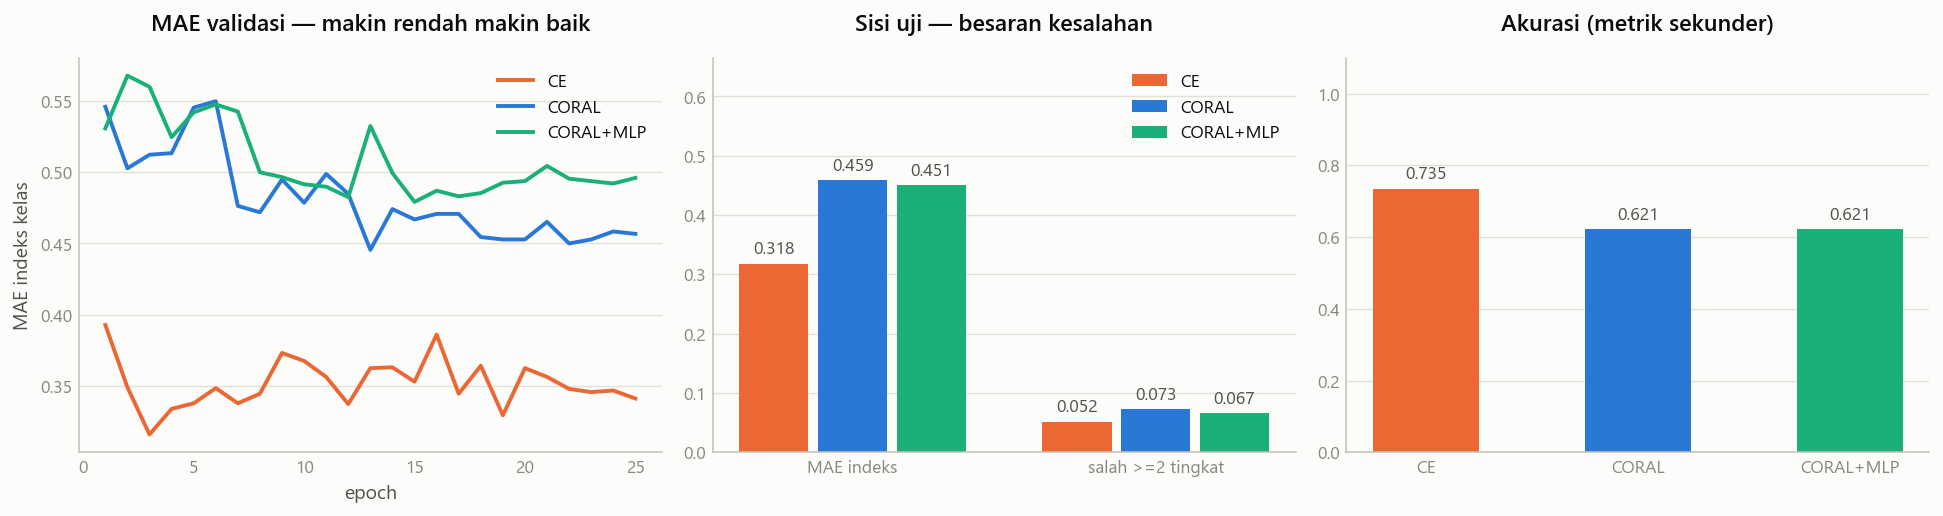

,akurasi,MAE_indeks,salah_>=2_tingkat,MAE vs CE,parameter head
CE,0.7352,0.3181,0.0519,0.0000,2052
CORAL,0.6213,0.4589,0.0735,44.2797,515
CORAL+MLP,0.6213,0.4508,0.0667,41.7373,131587


In [7]:
LBL_VARIAN = [l for _, l in VARIAN]
WARNA = {"CE": vs.CATEGORICAL[1], "CORAL": vs.CATEGORICAL[0],
         "CORAL+MLP": vs.CATEGORICAL[2]}

tab = pd.DataFrame(hasil).T[["akurasi", "MAE_indeks", "salah_>=2_tingkat"]]
tab["MAE vs CE"] = [(hasil[l]["MAE_indeks"] - hasil["CE"]["MAE_indeks"])
                    / hasil["CE"]["MAE_indeks"] * 100 for l in tab.index]
tab["parameter head"] = [sum(p.numel() for p in model_akhir[l][0].head.parameters())
                         for l in tab.index]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

ax = axes[0]
for lbl in LBL_VARIAN:
    h = hist[lbl]
    if "val_mae" in h:
        ax.plot(h["epoch"], h["val_mae"], label=lbl, color=WARNA[lbl])
ax.set_xlabel("epoch"); ax.set_ylabel("MAE indeks kelas")
ax.set_title("MAE validasi — makin rendah makin baik"); ax.legend()

ax = axes[1]
m = ["MAE_indeks", "salah_>=2_tingkat"]
x = np.arange(len(m)); w = 0.26
for i, lbl in enumerate(LBL_VARIAN):
    b = ax.bar(x + (i - 1) * w, [hasil[lbl][k] for k in m], width=w * 0.88,
               color=WARNA[lbl], label=lbl)
    vs.label_bars(ax, b, fmt="{:.3f}")
ax.set_xticks(x); ax.set_xticklabels(["MAE indeks", "salah >=2 tingkat"])
ax.set_title("Sisi uji — besaran kesalahan"); ax.legend()
ax.set_ylim(0, max(hasil[l]["MAE_indeks"] for l in LBL_VARIAN) * 1.45)

ax = axes[2]
b = ax.bar(range(len(LBL_VARIAN)), [hasil[l]["akurasi"] for l in LBL_VARIAN],
           color=[WARNA[l] for l in LBL_VARIAN], width=0.5)
vs.label_bars(ax, b, fmt="{:.3f}")
ax.set_xticks(range(len(LBL_VARIAN)))
ax.set_xticklabels(LBL_VARIAN, fontsize=9)
ax.set_ylim(0, 1.1); ax.set_title("Akurasi (metrik sekunder)")

plt.tight_layout(); vs.show()
tab.round(4)

### Kapasitas head — akar persoalannya

CORAL baku memampatkan seluruh vektor fitur menjadi **satu skor skalar**, lalu
digeser K-1 bias. Itulah hambatan rank-1: model dipaksa mengasumsikan
kematangan dapat diproyeksikan ke satu garis lurus. Kolom `parameter head`
di tabel atas menunjukkan berapa besar biaya asumsi itu.

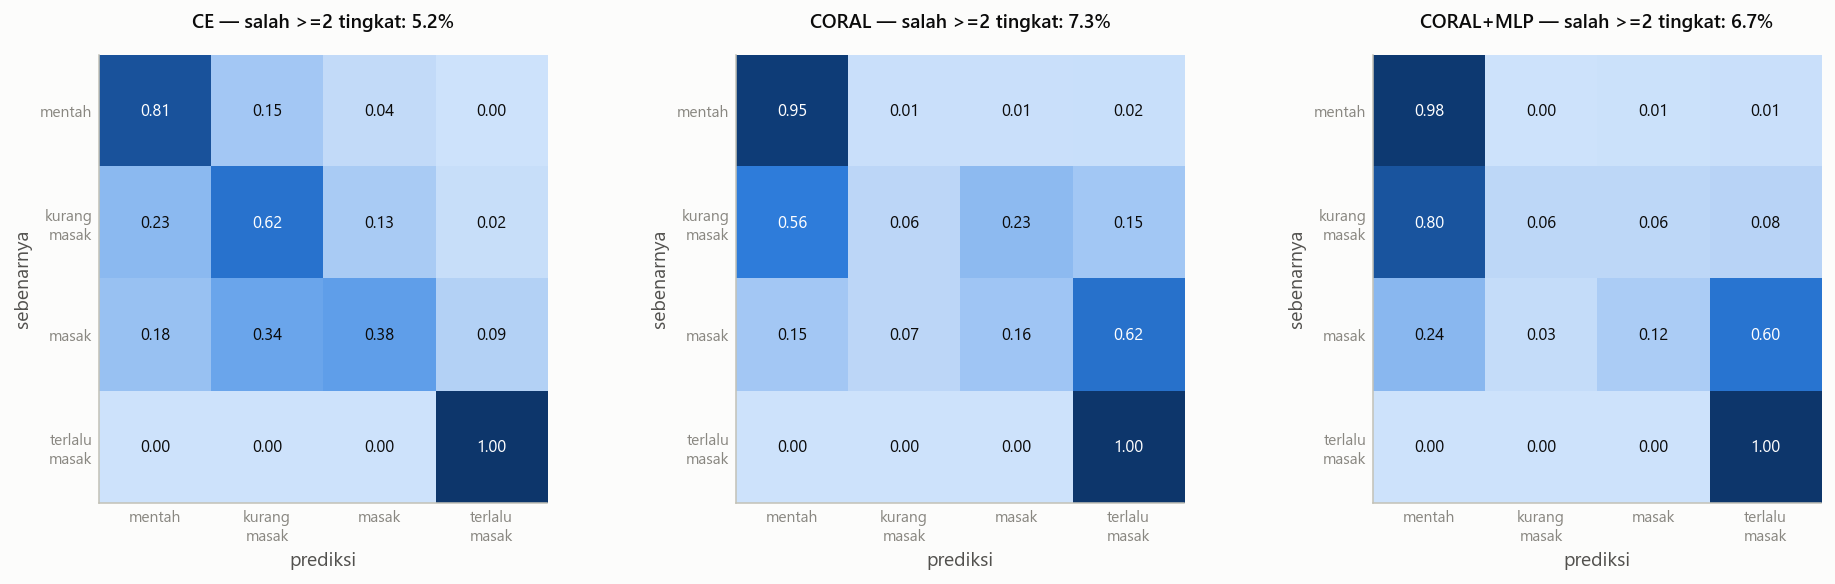

In [8]:
from sklearn.metrics import confusion_matrix
LBLK = ["mentah", "kurang\nmasak", "masak", "terlalu\nmasak"]

n = len(LBL_VARIAN)
fig, axes = plt.subplots(1, n, figsize=(4.6 * n, 4.2))
cmap = plt.matplotlib.colors.LinearSegmentedColormap.from_list("seq", vs.SEQUENTIAL)
for ax, lbl in zip(np.atleast_1d(axes), LBL_VARIAN):
    _, pr_, y_ = model_akhir[lbl]
    cm = confusion_matrix(y_, pr_, labels=range(4), normalize="true")
    ax.imshow(cm, cmap=cmap, vmin=0, vmax=1)
    ax.set_xticks(range(4)); ax.set_xticklabels(LBLK, fontsize=8)
    ax.set_yticks(range(4)); ax.set_yticklabels(LBLK, fontsize=8)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{cm[i,j]:.2f}", ha="center", va="center",
                    fontsize=8.5, color="#ffffff" if cm[i,j] > 0.55 else vs.INK)
    jauh = float((np.abs(np.array(pr_) - np.array(y_)) >= 2).mean())
    ax.set_xlabel("prediksi"); ax.set_ylabel("sebenarnya")
    ax.set_title(f"{lbl} — salah >=2 tingkat: {jauh:.1%}", fontsize=10)
    ax.grid(False)
plt.tight_layout(); vs.show()

### Sebaran besar kesalahan

Inti klaim model ordinal bukan "lebih sering benar", melainkan **"kalau salah,
salahnya lebih dekat"**. Grafik inilah yang menguji klaim itu secara langsung —
akurasi tidak bisa membedakan meleset satu tingkat dari meleset tiga.

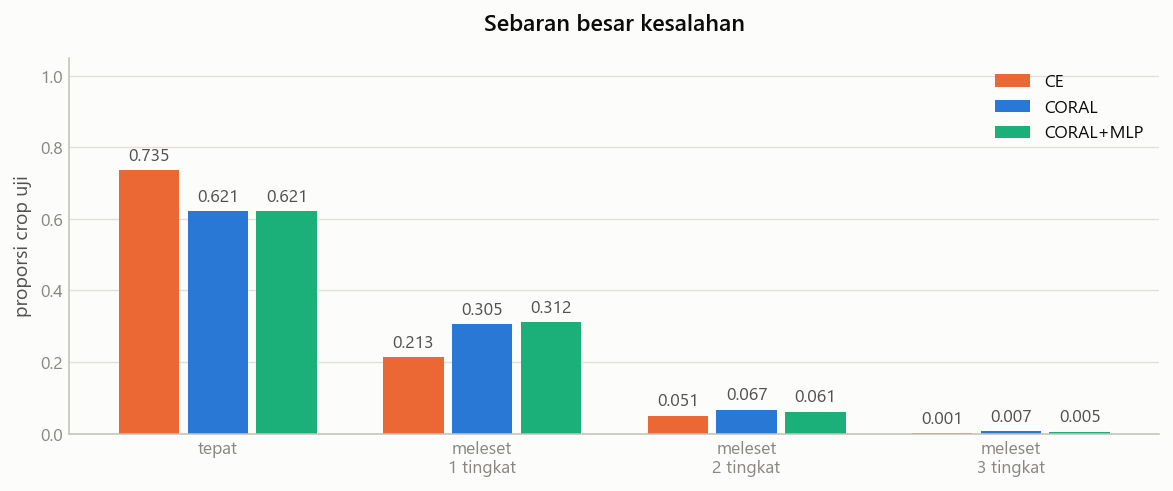

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 3.6))
x = np.arange(4); w = 0.26
for i, lbl in enumerate(LBL_VARIAN):
    _, pr_, y_ = model_akhir[lbl]
    d = np.abs(np.array(pr_) - np.array(y_))
    frac = [float((d == k).mean()) for k in range(4)]
    b = ax.bar(x + (i - 1) * w, frac, width=w * 0.88, color=WARNA[lbl], label=lbl)
    vs.label_bars(ax, b, fmt="{:.3f}")
ax.set_xticks(x)
ax.set_xticklabels(["tepat", "meleset\n1 tingkat", "meleset\n2 tingkat",
                    "meleset\n3 tingkat"])
ax.set_ylabel("proporsi crop uji"); ax.set_ylim(0, 1.05)
ax.set_title("Sebaran besar kesalahan"); ax.legend()
plt.tight_layout(); vs.show()

### Uji risiko jalan pintas — di sini baru benar-benar bermakna

66 dari 91 tumpukan hanya berisi satu tingkat kematangan. Pada tumpukan
seperti itu, model bisa lulus tanpa membedakan tandan sama sekali — cukup
mengenali konteks keseluruhan. Karena head ordinal **memang menilai
kematangan**, risiko itu nyata di sini, tidak seperti pada detektor.

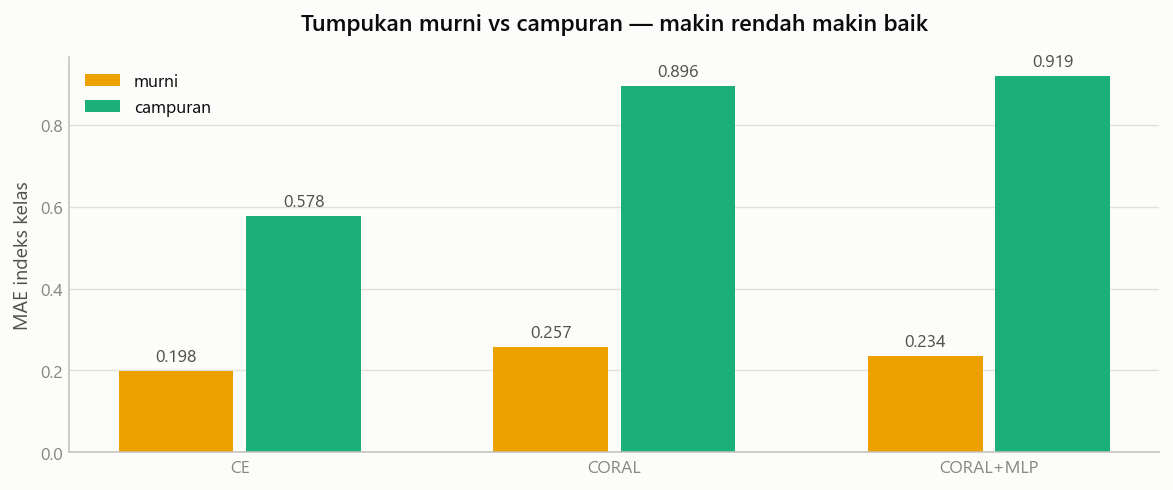

,varian,kelompok,akurasi,MAE_indeks,salah_>=2_tingkat
0,CE,murni,0.8365,0.1980,0.0335
1,CE,campuran,0.5160,0.5778,0.0917
2,CORAL,murni,0.7931,0.2571,0.0414
3,CORAL,campuran,0.2495,0.8955,0.1429
4,CORAL+MLP,murni,0.8000,0.2345,0.0276
5,CORAL+MLP,campuran,0.2345,0.9190,0.1514


In [10]:
hasil_pisah = {}
for lbl in LBL_VARIAN:
    m, _, _ = model_akhir[lbl]
    mode = dict(VARIAN[::1])
    mode = [k for k, v in VARIAN if v == lbl][0]
    baris = {}
    for murni, nama in [(True, "murni"), (False, "campuran")]:
        sub = crops[(crops.split == "test") & (crops.murni == murni)]
        if sub.empty:
            continue
        dl = DataLoader(CropDS(sub, tf_eval), batch_size=BS, num_workers=0)
        met, _, _ = evaluasi(m, dl, 4, mode)
        baris[nama] = met
    hasil_pisah[lbl] = baris

rows = []
for lbl, d in hasil_pisah.items():
    for nama, met in d.items():
        rows.append({"varian": lbl, "kelompok": nama, **met})
pisah_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8.5, 3.6))
x = np.arange(len(LBL_VARIAN)); w = 0.34
for i, (nama, col) in enumerate([("murni", vs.CATEGORICAL[3]),
                                 ("campuran", vs.CATEGORICAL[2])]):
    vals = [hasil_pisah[l].get(nama, {}).get("MAE_indeks", np.nan)
            for l in LBL_VARIAN]
    b = ax.bar(x + (i - 0.5) * w, vals, width=w * 0.9, color=col, label=nama)
    vs.label_bars(ax, b, fmt="{:.3f}")
ax.set_xticks(x); ax.set_xticklabels(LBL_VARIAN, fontsize=9)
ax.set_ylabel("MAE indeks kelas")
ax.set_title("Tumpukan murni vs campuran — makin rendah makin baik")
ax.legend()
plt.tight_layout(); vs.show()

pisah_df.round(4)

In [11]:
# Simpan bobot terbaik + ringkasan angka
W = ROOT / "ai" / "weights"
W.mkdir(parents=True, exist_ok=True)
best_mode = "coral" if hasil["CORAL"]["MAE_indeks"] <= hasil["CE"]["MAE_indeks"] else "ce"
best_lbl = "CORAL" if best_mode == "coral" else "CE"
torch.save({"state_dict": model_akhir[best_lbl][0].state_dict(),
            "mode": best_mode, "n_kelas": 4, "size": SIZE,
            "mean": MEAN, "std": STD},
           W / "head_ordinal.pt")

out = ROOT / "docs" / "hasil_head_ordinal.json"
out.write_text(json.dumps({
    "hasil_uji": hasil,
    "epoch": {k: int(len(v)) for k, v in hist.items()},
    "terpilih": best_lbl,
    "crop": {"train": int((crops.split == "train").sum()),
             "val": int((crops.split == "val").sum()),
             "test": int((crops.split == "test").sum())},
}, indent=2, default=float), encoding="utf-8")
print("bobot   ->", W / "head_ordinal.pt")
print("angka   ->", out)
print("terpilih:", best_lbl)

bobot   -> D:\LOMBA\COMPFEST\neraca-minyak\ai\weights\head_ordinal.pt
angka   -> D:\LOMBA\COMPFEST\neraca-minyak\docs\hasil_head_ordinal.json
terpilih: CE


## Kesimpulan

Dua temuan. Yang kedua jauh lebih penting daripada yang pertama, dan mengubah
apa yang boleh diklaim tentang sistem ini.

---

### 1. CORAL kalah dari cross-entropy — dan bukan karena kapasitas

| Varian | Akurasi | MAE indeks | Salah ≥2 tingkat | Parameter head |
|---|---|---|---|---|
| **CE** | **0,7352** | **0,3181** | **5,19%** | 2.052 |
| CORAL | 0,6213 | 0,4589 | 7,35% | 515 |
| CORAL+MLP | 0,6213 | 0,4508 | 6,67% | 131.587 |

CORAL kalah bahkan pada **MAE indeks** — metrik yang justru menjadi alasan
utama memakainya — dan pada **salah ≥2 tingkat**, yaitu persis jenis kesalahan
yang seharusnya dicegah oleh struktur ordinal.

**Hipotesis awal: hambatan rank-1.** CORAL baku memampatkan 512 dimensi fitur
menjadi satu skor lewat satu lapisan linear, sehingga kapasitas kepalanya hanya
seperempat CE. Dugaannya, itu penyebab kekalahannya.

**Hipotesis itu diuji dan terbantah.** Varian CORAL+MLP menambah kapasitas
kepala **256 kali lipat** (515 → 131.587 parameter) sambil tetap
mempertahankan jaminan urutan. Perbaikannya hanya 1,8% pada MAE
(0,4589 → 0,4508) dan akurasinya sama persis. Kapasitas bukan penyebabnya.

Kesimpulan yang tersisa: pada data ini, memaksa keluaran melewati satu skor
skalar berjenjang **memang merugikan**, terlepas dari seberapa kaya
representasi sebelumnya. Kematangan tandan dalam crop tampaknya tidak dapat
diringkas menjadi satu dimensi tunggal.

Karena itu **head yang dipakai adalah CE**, dan hasil negatif ini dilaporkan
apa adanya beserta eksperimen yang mengujinya.

---

### 2. Model belajar mengenali TUMPUKAN, bukan membedakan TANDAN

Ini temuan yang menentukan, dan datang dari pemisahan evaluasi menurut karakter
tumpukan:

| Varian | Kelompok | Akurasi | MAE indeks | Salah ≥2 tingkat |
|---|---|---|---|---|
| CE | murni | 0,8365 | 0,1980 | 3,35% |
| **CE** | **campuran** | **0,5160** | **0,5778** | 9,17% |
| CORAL | murni | 0,7931 | 0,2571 | 4,14% |
| **CORAL** | **campuran** | **0,2495** | **0,8955** | 14,29% |
| CORAL+MLP | murni | 0,8000 | 0,2345 | 2,76% |
| **CORAL+MLP** | **campuran** | **0,2345** | **0,9190** | 15,14% |

Dengan empat kelas, tebakan acak menghasilkan akurasi 0,25.

> **Kedua varian CORAL pada tumpukan campuran berada di 0,2495 dan 0,2345 —
> setara tebakan acak.** Pada kasus yang paling menyerupai muatan truk
> sungguhan, keduanya praktis tidak mempelajari apa pun yang dapat
> dipindahkan.

CE bertahan lebih baik (0,5160, dua kali lipat tebakan acak) tetapi tetap
runtuh dari 0,8365 di tumpukan murni.

**Mekanismenya jelas.** Notebook 01 menemukan 66 dari 91 tumpukan hanya berisi
satu tingkat kematangan. Crop dipotong dengan padding 10%, sehingga tiap crop
membawa serta latar, pencahayaan, sudut kamera, dan potongan tandan tetangga di
tepinya. Petunjuk itu cukup untuk mengenali **tumpukan mana** yang sedang
dilihat — dan karena mayoritas tumpukan berkelas tunggal, mengenali tumpukan
sama saja dengan mengetahui labelnya, tanpa pernah benar-benar memeriksa tandan
yang dimaksud.

Model lulus ujian dengan menghafal ruangannya, bukan menjawab soalnya.

**Catatan kejujuran metodologis.** Sebagian selisih ini bersifat bawaan, bukan
murni jalan pintas: pada tumpukan murni semua crop berlabel sama, sehingga
menebak satu kelas dominan sudah benar untuk seluruh tumpukan. Tetapi angka
0,2345–0,2495 pada tumpukan campuran tidak dapat dijelaskan oleh kemudahan
tugas — itu batas bawah tebakan acak, dan menunjukkan tidak ada kemampuan
diskriminasi antar tandan yang tersisa.

---

### 3. Jarak domain terukur

| Tahap | Akurasi validasi |
|---|---|
| Pra-latih, citra buah tunggal bersih | 0,9119 |
| Setelah penyesuaian, crop dari tumpukan | ~0,70 |

Penurunan ini mengukur jarak domain yang diprediksi Notebook 03, dan
membenarkan keputusan menyusul pra-latih dengan penyesuaian pada crop asli.

---

### Konsekuensi untuk sistem

1. **Angka yang dilaporkan untuk komponen kematangan adalah angka pada
   tumpukan campuran (akurasi 0,516), bukan angka gabungan (0,735).** Angka
   gabungan terlalu optimistis karena didominasi tumpukan murni yang tidak
   mewakili muatan truk nyata.

2. **Komponen ini belum layak dipakai sebagai dasar keputusan finansial.**
   Ambang tindakan yang sudah dirancang di Model 6 justru menjadi relevan di
   sini: keluaran head kematangan harus masuk kategori keyakinan rendah sampai
   ada bukti yang lebih baik.

3. **Arah perbaikan yang jelas**, sesuai urutan biaya:
   - Latih ulang **hanya pada 25 tumpukan campuran**, sehingga jalan pintas
     tidak lagi berbuah
   - Perkecil padding crop menjadi nol, dan hapus konteks tepi
   - Augmentasi yang merusak petunjuk latar (penggantian latar, pemotongan
     agresif)
   - Kumpulkan tumpukan campuran tambahan — akar masalahnya adalah komposisi
     dataset, bukan arsitektur

4. **Detektor tidak terpengaruh temuan ini.** Notebook 04 menunjukkan detektor
   justru sedikit lebih baik pada tumpukan campuran (mAP@50 0,991 vs 0,938),
   sehingga tidak ada indikasi jalan pintas di sana.

---

### Nilai temuan ini

Sistem yang melaporkan akurasi 0,735 tanpa memisahkan tumpukan murni dan
campuran akan terlihat jauh lebih baik daripada kenyataannya — dan kegagalan
itu baru ketahuan saat dipasang di gerbang pabrik sungguhan, tempat semua
muatan bercampur.

Pemisahan evaluasi inilah yang menangkapnya, dan itu hanya mungkin karena
Notebook 01 lebih dulu menemukan bahwa 66 dari 91 tumpukan berkelas tunggal.